In [180]:
# Urban Tree Equity Analysis
# Step 1: Data Collection

print("Notebook initialized")

Notebook initialized


In [181]:
import pandas as pd

parks = pd.read_csv("Parks_and_Recreation_Areas.csv")
income = pd.read_csv("ACS_5-Year_Economic_Characteristics_DC_Ward.csv")

parks.head()


,NAME,ADDRESS,USE_TYPE,PROPID,ACTIVE,DIAMOND60,DIAMOND90,BBCOURT,FBFIELD,SOCCERJR,...,SSL,COMMENTS,DATE_ACQUIRED,SE_ANNO_CAD_DATA,GLOBALID,CREATED,EDITED,OBJECTID,SHAPEAREA,SHAPELEN
0,Plymouth Circle,"Plymouth St. & Parkside Ln., NW",CIRCLE,DPR_0616,Y,NaN,NaN,NaN,NaN,NaN,...,RES 06160000,TOJ for Comp Plan,NaN,NaN,{0304E325-2A15-4BF8-AB08-2D12BCE51D32},NaN,NaN,1,0,0
1,Triangle Park RES 0566,"Plymouth Street at Sudbury Lane, NW",MEDIAN,DPR_0566,Y,NaN,NaN,NaN,NaN,NaN,...,RES 5660000,TOJ for Comp Plan,NaN,NaN,{1B70BAF1-D84D-44E3-8ABE-D27CBD3B8CB7},NaN,NaN,2,0,0
2,Shepherd Field,7800 14TH STREET NW,REC CENTER GROUNDS,DPR_0437,Y,NaN,NaN,NaN,NaN,NaN,...,Multiple Lots,Subdivision Book 158 Page 37 (TOJ for Recreati...,1972/11/14 05:00:00+00,NaN,{CE53A23E-FC8A-4CB6-A508-8607D7A205EA},NaN,2024/08/26 22:26:47+00,3,0,0
3,Marvin Caplan Memorial Park,"Alaska Ave.,13th St.,Holly St.,NW",TRIANGLE,DPR_0340,Y,NaN,NaN,NaN,NaN,NaN,...,RES 03400000,Subdivision Book 162 Page 2 (TOJ for Recreatio...,1972/12/14 05:00:00+00,NaN,{78998939-A911-464C-B3F0-73ED8E9DD982},NaN,NaN,4,0,0
4,Pinehurst Circle,"Western Ave and Pinhurst Circle, NW",PARK,DPR_0564,Y,NaN,NaN,NaN,NaN,NaN,...,RES 05640000,TOJ for Comp Plan,1972/12/14 05:00:00+00,NaN,{A452AE1D-FD72-41DD-BE25-D78A4FE0793D},NaN,NaN,5,0,0


In [182]:
income.head()

,GEOID,NAMELSAD,NAME,DP03_0001E,DP03_0002E,DP03_0003E,DP03_0004E,DP03_0005E,DP03_0006E,DP03_0007E,...,DP03_0130PE,DP03_0131PE,DP03_0132PE,DP03_0133PE,DP03_0134PE,DP03_0135PE,DP03_0136PE,DP03_0137PE,SHAPEAREA,SHAPELEN
0,11002,Ward 2,Ward 2 (2022); District of Columbia,74512,55131,54812,52969,1843,319,19381,...,8.1,7.4,8.8,11.5,11.6,10.6,4.7,15.2,0,0
1,11004,Ward 4,Ward 4 (2022); District of Columbia,65891,47935,47871,45084,2787,64,17956,...,10.0,5.5,11.9,8.2,8.1,8.5,6.4,16.3,0,0
2,11007,Ward 7,Ward 7 (2022); District of Columbia,69977,43543,43317,37105,6212,226,26434,...,30.7,29.9,31.0,19.5,19.6,19.1,20.1,29.2,0,0
3,11001,Ward 1,Ward 1 (2022); District of Columbia,68528,55882,55666,53508,2158,216,12646,...,24.1,24.0,24.2,9.5,8.4,19.0,11.2,12.1,0,0
4,11008,Ward 8,Ward 8 (2022); District of Columbia,64557,41337,39727,34221,5506,1610,23220,...,34.8,32.0,35.9,23.6,22.6,29.8,25.5,30.0,0,0


In [183]:
parks.columns

Index(['NAME', 'ADDRESS', 'USE_TYPE', 'PROPID', 'ACTIVE', 'DIAMOND60',
       'DIAMOND90', 'BBCOURT', 'FBFIELD', 'SOCCERJR', 'SOCCERREG', 'TENNISCT',
       'VOLLEYB', 'SKATEPARK', 'WOODLAND', 'VSTRSHCAN', 'DMPSTR', 'PICNIC',
       'PLYGRD', 'TOTLOT', 'INSWIM', 'OUTSWIM', 'SPRAYPARK', 'UTILBX',
       'TRAFPOLE', 'UTILPOLE', 'BUSSTP', 'LOCK_', 'NMZ', 'DRINKFOUNT',
       'BENCHES', 'ATHLIGHT', 'LNDSCPBED', 'TOTIMPV', 'SIGNS', 'TURFONLY',
       'FENCE', 'TOPO', 'COMMGAR', 'WARD', 'AREA_', 'ZONE_', 'PARKPARTN',
       'RES_NUM', 'ADJ_SCHOOL_SITE', 'SSL', 'COMMENTS', 'DATE_ACQUIRED',
       'SE_ANNO_CAD_DATA', 'GLOBALID', 'CREATED', 'EDITED', 'OBJECTID',
       'SHAPEAREA', 'SHAPELEN'],
      dtype='object')

In [184]:
income.columns

Index(['GEOID', 'NAMELSAD', 'NAME', 'DP03_0001E', 'DP03_0002E', 'DP03_0003E',
       'DP03_0004E', 'DP03_0005E', 'DP03_0006E', 'DP03_0007E',
       ...
       'DP03_0130PE', 'DP03_0131PE', 'DP03_0132PE', 'DP03_0133PE',
       'DP03_0134PE', 'DP03_0135PE', 'DP03_0136PE', 'DP03_0137PE', 'SHAPEAREA',
       'SHAPELEN'],
      dtype='object', length=157)

In [185]:
parks.shape

(252, 55)

In [186]:
income.shape

(8, 157)

In [187]:


# DP03_0062E DP03_0062E is the Census variable representing the Median Household Income
income_clean = income[['NAMELSAD', 'DP03_0062E']].copy()
income_clean = income_clean.rename(columns={
    'NAMELSAD': 'ward',
    'DP03_0062E': 'median_income'
})
income_clean['ward'] = income_clean['ward'].str.extract('(\d+)').astype(int)

income_clean.head()

,ward,median_income
0,2,131405
1,4,128210
2,7,69109
3,1,126387
4,8,50931


In [188]:
# count of parks missing ward data
parks['WARD'].isna().sum()

np.int64(2)

In [189]:
# Removing 2 parks without Ward data
parks = parks.dropna(subset=['WARD'])


parks['ward'] = parks['WARD'].astype(int)
parks_count = parks.groupby('ward').size().reset_index(name='park_count')
parks_count.head()

,ward,park_count
0,1,32
1,2,19
2,3,34
3,4,37
4,5,32


In [190]:
df = parks_count.merge(income_clean, on='ward')
df.head()

,ward,park_count,median_income
0,1,32,126387
1,2,19,131405
2,3,34,141849
3,4,37,128210
4,5,32,97814


In [191]:
df.describe()


,ward,park_count,median_income
count,8.00000,8.000000,8.000000
mean,4.50000,31.250000,110469.000000
std,2.44949,12.020815,34157.752632
min,1.00000,17.000000,50931.000000
25%,2.75000,22.750000,90637.750000
50%,4.50000,32.000000,127298.500000
75%,6.25000,34.750000,133065.500000
max,8.00000,55.000000,141849.000000


In [192]:
df[['park_count', 'median_income']].corr()

,park_count,median_income
park_count,1.000000,0.604524
median_income,0.604524,1.000000


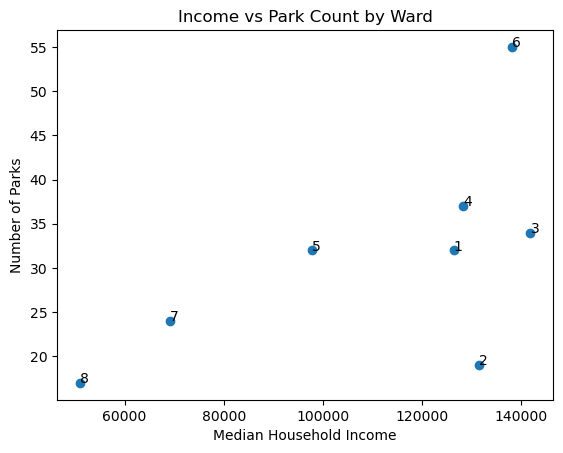

In [193]:
# median income to number of parks by ward
import matplotlib.pyplot as plt

plt.scatter(df['median_income'], df['park_count'])
for i in range(len(df)):
    plt.text(df['median_income'][i], df['park_count'][i], str(df['ward'][i]))

plt.xlabel('Median Household Income')
plt.ylabel('Number of Parks')
plt.title('Income vs Park Count by Ward')

plt.show()

In [194]:
# 2 potential outliers at ward 6 and ward 2
# Both have higher income but ward 6 has a lot of parks and ward 2 has comparitavely fewer. 
# Potential factor could be population size -- bringing in another dataset to investigate.

In [195]:
population = pd.read_csv("ACS_5-Year_Demographic_Characteristics_DC_Ward.csv")
population.columns
population['NAMELSAD'].head()



0    Ward 2
1    Ward 4
2    Ward 7
3    Ward 1
4    Ward 8
Name: NAMELSAD, dtype: object

In [196]:
population_clean = population[['NAMELSAD', 'DP05_0001E']].copy()
population_clean = population_clean.rename(columns={
    'NAMELSAD': 'ward',
    'DP05_0001E': 'population'
})

In [197]:
population_clean.head()


,ward,population
0,Ward 2,78878
1,Ward 4,85587
2,Ward 7,90898
3,Ward 1,79373
4,Ward 8,86509


In [198]:
population_clean['ward'] = population_clean['ward'].str.extract('(\d+)').astype(int)
population_clean.head()


,ward,population
0,2,78878
1,4,85587
2,7,90898
3,1,79373
4,8,86509


In [199]:
population_clean['population'].dtype

dtype('int64')

In [200]:
df = df.merge(population_clean, on='ward')

In [201]:
df.head()

,ward,park_count,median_income,population
0,1,32,126387,79373
1,2,19,131405,78878
2,3,34,141849,78404
3,4,37,128210,85587
4,5,32,97814,88426


In [202]:
df['parks_per_10k'] = df['park_count'] / (df['population'] / 10000)
df.head()

,ward,park_count,median_income,population,parks_per_10k
0,1,32,126387,79373,4.031598
1,2,19,131405,78878,2.408783
2,3,34,141849,78404,4.336513
3,4,37,128210,85587,4.323086
4,5,32,97814,88426,3.618845


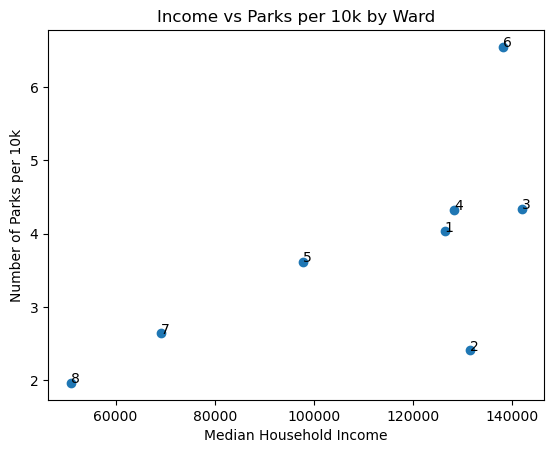

In [203]:
# median income to number of parks per 10k by ward

plt.scatter(df['median_income'], df['parks_per_10k'])
for i in range(len(df)):
    plt.text(df['median_income'][i], df['parks_per_10k'][i], str(df['ward'][i]))

plt.xlabel('Median Household Income')
plt.ylabel('Number of Parks per 10k')
plt.title('Income vs Parks per 10k by Ward')

plt.show()

In [204]:
df[['parks_per_10k', 'median_income']].corr()

,parks_per_10k,median_income
parks_per_10k,1.000000,0.678459
median_income,0.678459,1.000000


In [205]:
df['expected_parks'] = df['median_income'].rank()
df[['ward','park_count','median_income']]


,ward,park_count,median_income
0,1,32,126387
1,2,19,131405
2,3,34,141849
3,4,37,128210
4,5,32,97814
5,6,55,138047
6,7,24,69109
7,8,17,50931


In [206]:
df['parks_z'] = (df['park_count'] - df['park_count'].mean()) / df['park_count'].std()
df['income_z'] = (df['median_income'] - df['median_income'].mean()) / df['median_income'].std()

df.head(10)


,ward,park_count,median_income,population,parks_per_10k,expected_parks,parks_z,income_z
0,1,32,126387,79373,4.031598,4.0,0.062392,0.466014
1,2,19,131405,78878,2.408783,6.0,-1.019066,0.612921
2,3,34,141849,78404,4.336513,8.0,0.228770,0.918679
3,4,37,128210,85587,4.323086,5.0,0.478337,0.519384
4,5,32,97814,88426,3.618845,3.0,0.062392,-0.370487
5,6,55,138047,84004,6.547307,7.0,1.975740,0.807372
6,7,24,69109,90898,2.640322,2.0,-0.603120,-1.210852
7,8,17,50931,86509,1.965113,1.0,-1.185444,-1.743030


In [207]:
utc = pd.read_csv("Urban_Tree_Canopy_by_Ward_in_2020.csv")
utc_clean = utc[['WARD', 'TCAN_PCT', 'VEG_PCT']].copy()

utc_clean = utc_clean.rename(columns={
    'WARD': 'ward',
    'TCAN_PCT' : 'tree_canopy_percentage',
    'VEG_PCT' : 'vegetation_cover_percentage'
})
utc_clean.head()


,ward,tree_canopy_percentage,vegetation_cover_percentage
0,4,49.43,14.44
1,3,56.46,11.91
2,5,29.01,21.43
3,1,23.76,7.37
4,2,20.05,12.45


In [208]:
df = df.merge(utc_clean, on='ward')
df.head()

,ward,park_count,median_income,population,parks_per_10k,expected_parks,parks_z,income_z,tree_canopy_percentage,vegetation_cover_percentage
0,1,32,126387,79373,4.031598,4.0,0.062392,0.466014,23.76,7.37
1,2,19,131405,78878,2.408783,6.0,-1.019066,0.612921,20.05,12.45
2,3,34,141849,78404,4.336513,8.0,0.228770,0.918679,56.46,11.91
3,4,37,128210,85587,4.323086,5.0,0.478337,0.519384,49.43,14.44
4,5,32,97814,88426,3.618845,3.0,0.062392,-0.370487,29.01,21.43


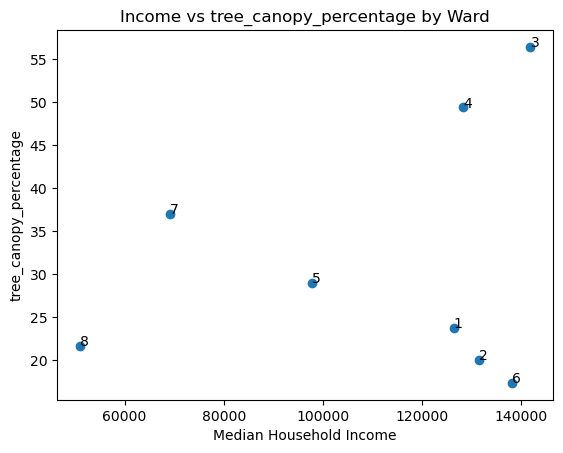

In [209]:
plt.scatter(df['median_income'], df['tree_canopy_percentage'])
for i in range(len(df)):
    plt.text(df['median_income'][i], df['tree_canopy_percentage'][i], str(df['ward'][i]))

plt.xlabel('Median Household Income')
plt.ylabel('tree_canopy_percentage')
plt.title('Income vs tree_canopy_percentage by Ward')

plt.show()

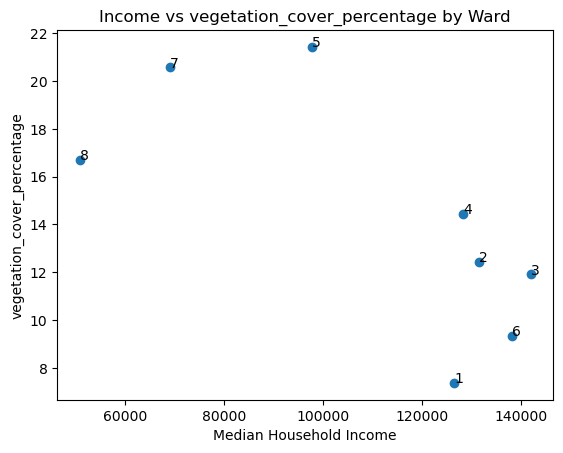

In [210]:
plt.scatter(df['median_income'], df['vegetation_cover_percentage'])
for i in range(len(df)):
    plt.text(df['median_income'][i], df['vegetation_cover_percentage'][i], str(df['ward'][i]))

plt.xlabel('Median Household Income')
plt.ylabel('vegetation_cover_percentage')
plt.title('Income vs vegetation_cover_percentage by Ward')

plt.show()

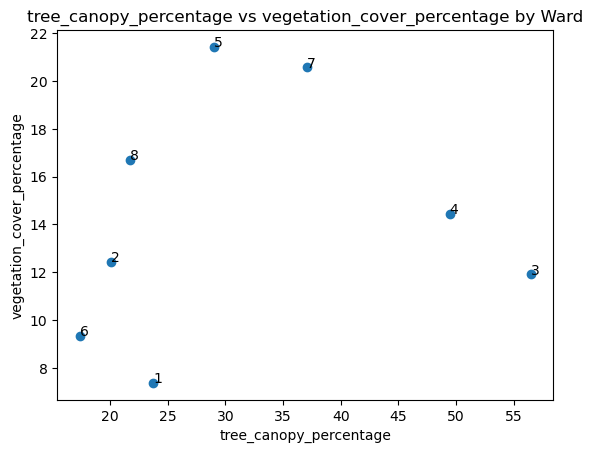

In [211]:
plt.scatter(df['tree_canopy_percentage'], df['vegetation_cover_percentage'])
for i in range(len(df)):
    plt.text(df['tree_canopy_percentage'][i], df['vegetation_cover_percentage'][i], str(df['ward'][i]))

plt.xlabel('tree_canopy_percentage')
plt.ylabel('vegetation_cover_percentage')
plt.title('tree_canopy_percentage vs vegetation_cover_percentage by Ward')

plt.show()

In [212]:
df.head(10)


,ward,park_count,median_income,population,parks_per_10k,expected_parks,parks_z,income_z,tree_canopy_percentage,vegetation_cover_percentage
0,1,32,126387,79373,4.031598,4.0,0.062392,0.466014,23.76,7.37
1,2,19,131405,78878,2.408783,6.0,-1.019066,0.612921,20.05,12.45
2,3,34,141849,78404,4.336513,8.0,0.228770,0.918679,56.46,11.91
3,4,37,128210,85587,4.323086,5.0,0.478337,0.519384,49.43,14.44
4,5,32,97814,88426,3.618845,3.0,0.062392,-0.370487,29.01,21.43
5,6,55,138047,84004,6.547307,7.0,1.975740,0.807372,17.38,9.33
6,7,24,69109,90898,2.640322,2.0,-0.603120,-1.210852,37.08,20.57
7,8,17,50931,86509,1.965113,1.0,-1.185444,-1.743030,21.70,16.70
